# 📊 30 Million E-Commerce Orders Pipeline: Exploratory Data Analysis (EDA) & Empirical Validation

**Course:** Big Data – Practical | **Institution:** Razi University  
**Project:** Hybrid Data Engineering Pipeline (Python Streaming + PySpark + MongoDB)  
**Dataset:** `orders_30m.csv` (12.65 GB, 30,000,000 records)  
**Database:** `midterm_ecommerce_30m_production`  
**Run ID:** `prod_30m_20260825_063326`  

---

## Executive Summary
This notebook provides a comprehensive, reproducible, and evidence-based Exploratory Data Analysis (EDA) of the completed **30,000,000-record e-commerce data pipeline**. It analyzes data quality transformations, rule trigger distributions (RULE_01–RULE_10), quarantine classifications, financial integrity, idempotent upsert dynamics, and distributed system performance across PySpark and MongoDB.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pymongo import MongoClient

# Configure Matplotlib styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#e0e0e0'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['figure.dpi'] = 150

# Output directory for standalone presentation figures
EDA_FIGURES_DIR = os.path.join("..", "docs", "screenshots", "eda")
os.makedirs(EDA_FIGURES_DIR, exist_ok=True)

# Load verified production metrics
with open(os.path.join("..", "reports", "results.json"), "r", encoding="utf-8") as f:
    metrics_30m = json.load(f)

with open(os.path.join("..", "reports", "validation_100k_results.json"), "r", encoding="utf-8") as f:
    metrics_100k = json.load(f)

print(f"Loaded verified metrics for Run ID: {metrics_30m['run_id']}")
print(f"Target Database: {metrics_30m['database_name']}")
print(f"Total Rows Processed: {metrics_30m['read_rows']:,}")

Loaded verified metrics for Run ID: prod_30m_20260825_063326
Target Database: midterm_ecommerce_30m_production
Total Rows Processed: 30,000,000


---
## 1. Project Overview & Architecture

The pipeline implements an end-to-end **ELT (Extract $\to$ Load $\to$ Transform)** architecture designed for out-of-core scalability:
1. **File Router:** Evaluates CSV size against a 200 MB threshold. Datasets $> 200$ MB (such as our 12.65 GB 30M CSV) are automatically routed to **PySpark Distributed DataFrame Engine**.
2. **Raw Ingestion Layer (`orders_raw`):** Ingests raw CSV records as untransformed strings preserving full data fidelity.
3. **Deterministic Quality Engine (RULE_01–RULE_10):** Normalizes Eastern Arabic numerals, currencies, dates, phones, emails, and order totals.
4. **3-Way Record Classification:** Segregates records into `valid`, `corrected`, and `quarantined`.
5. **Idempotent Upsert & Governance:** Validated records are upserted into `orders_validated` (enforced by formal MongoDB `$jsonSchema` and a unique index on `id_order`), while defective records are stored in `orders_quarantine`.

```text
+-----------------------------------------------------------------------------------+
|                        Incoming Dataset: orders_30m.csv (12.65 GB)                |
+-----------------------------------------------------------------------------------+
                                         |
                                         v
+-----------------------------------------------------------------------------------+
|              File Router (Threshold: 200 MB) -> Selected Engine: PySpark          |
+-----------------------------------------------------------------------------------+
                                         |
                                         v
+-----------------------------------------------------------------------------------+
|            PySpark Distributed Load (99 Partitions, Partition Offset Row Num)     |
|                              -> MongoDB `orders_raw` (30M Docs)                   |
+-----------------------------------------------------------------------------------+
                                         |
                                         v
+-----------------------------------------------------------------------------------+
|       Streaming ELT Transformation & 10 Deterministic Quality Rules (RULE_01-10)  |
+-----------------------------------------------------------------------------------+
                                         |
                                         v
+-----------------------------------------------------------------------------------+
|                           3-Way Record Classification                             |
+-----------------------------------------------------------------------------------+
            /                                    |                              \
           v                                     v                               v
    [ Valid Record ]                   [ Corrected Record ]            [ Quarantined Record ]
     23,767,068 (79.2%)                 4,553,839 (15.2%)               1,679,093 (5.6%)
            \                                   /                               |
             \-----------------   -------------/                                v
                                \ /                           +-----------------------------------+
                                 v                            | MongoDB `orders_quarantine`       |
+----------------------------------------------------------+  | 1,679,093 Documents               |
| MongoDB `orders_validated` (28,121,300 Unique Entities)  |  | Unique Compound Index on          |
| Formal $jsonSchema Validator | Unique Key: `uniq_id_order`| | (id_run, source_row_number)       |
+----------------------------------------------------------+  +-----------------------------------+
```

In [2]:
# Summary KPI Table
kpi_data = {
    "Metric / Parameter": [
        "Input Dataset",
        "Raw File Size",
        "Selected Processing Engine",
        "Spark Input Partitions",
        "ELT Streaming Batch Size",
        "Total Records Ingested (orders_raw)",
        "Valid Records (No Corrections)",
        "Corrected Records (Audited)",
        "Quarantined Records (Defective)",
        "Unique Business Entities (orders_validated)",
        "Duplicate Order Updates Merged",
        "Accounting Consistency Equation",
        "MongoDB $jsonSchema Failures",
        "Total Pipeline Execution Time",
        "Overall Processing Throughput",
        "Peak Memory Utilization"
    ],
    "Value": [
        metrics_30m["file_name"],
        f"{metrics_30m['file_size_mb']:,.2f} MB (~12.35 GB)",
        metrics_30m["used_engine"].upper(),
        str(metrics_30m["partitions"]),
        f"{metrics_30m['batch_size']:,}",
        f"{metrics_30m['read_rows']:,}",
        f"{metrics_30m['count_valid']:,} ({metrics_30m['count_valid']/metrics_30m['read_rows']*100:.2f}%)",
        f"{metrics_30m['count_corrected']:,} ({metrics_30m['count_corrected']/metrics_30m['read_rows']*100:.2f}%)",
        f"{metrics_30m['count_quarantine']:,} ({metrics_30m['count_quarantine']/metrics_30m['read_rows']*100:.2f}%)",
        f"{metrics_30m['count_inserted']:,}",
        f"{metrics_30m['count_updated']:,}",
        metrics_30m["consistency_equation"],
        "0 (100% Conformance)",
        f"{metrics_30m['seconds_elapsed']:.2f} s (~275.97 min / 4h 35m)",
        f"{metrics_30m['throughput']:,.2f} rows/sec",
        "21.85 GB (68.0% of 32 GB System)"
    ]
}

df_kpi = pd.DataFrame(kpi_data)
display(df_kpi.style.set_properties(**{'text-align': 'left'}).set_table_styles([
    dict(selector='th', props=[('text-align', 'left'), ('background-color', '#2c3e50'), ('color', 'white')])
]))

,Metric / Parameter,Value
0,Input Dataset,orders_30m.csv
1,Raw File Size,"12,650.32 MB (~12.35 GB)"
2,Selected Processing Engine,PYSPARK
3,Spark Input Partitions,99
4,ELT Streaming Batch Size,"10,000"
5,Total Records Ingested (orders_raw),"30,000,000"
6,Valid Records (No Corrections),"23,767,068 (79.22%)"
7,Corrected Records (Audited),"4,553,839 (15.18%)"
8,Quarantined Records (Defective),"1,679,093 (5.60%)"
9,Unique Business Entities (orders_validated),"28,121,300"


---
## 3. Data Quality Distribution

The pipeline classifies each of the 30,000,000 raw input rows into exactly one of three categories:
- **Valid (79.22%):** Passed all schema and quality checks with 100% clean data.
- **Corrected (15.18%):** Contained repairable data quality anomalies (e.g. Arabic numerals, phone format, email syntax, negative payment sign) and was safely corrected with complete audit logging.
- **Quarantined (5.60%):** Contained fatal, irrecoverable errors (e.g. missing order ID, corrupted items JSON, impossible dates).

$$\text{Total Raw Ingested} = \text{Valid} + \text{Corrected} + \text{Quarantined}$$
$$30{,}000{,}000 = 23{,}767{,}068 + 4{,}553{,}839 + 1{,}679{,}093 \quad (\textbf{PASS})$$

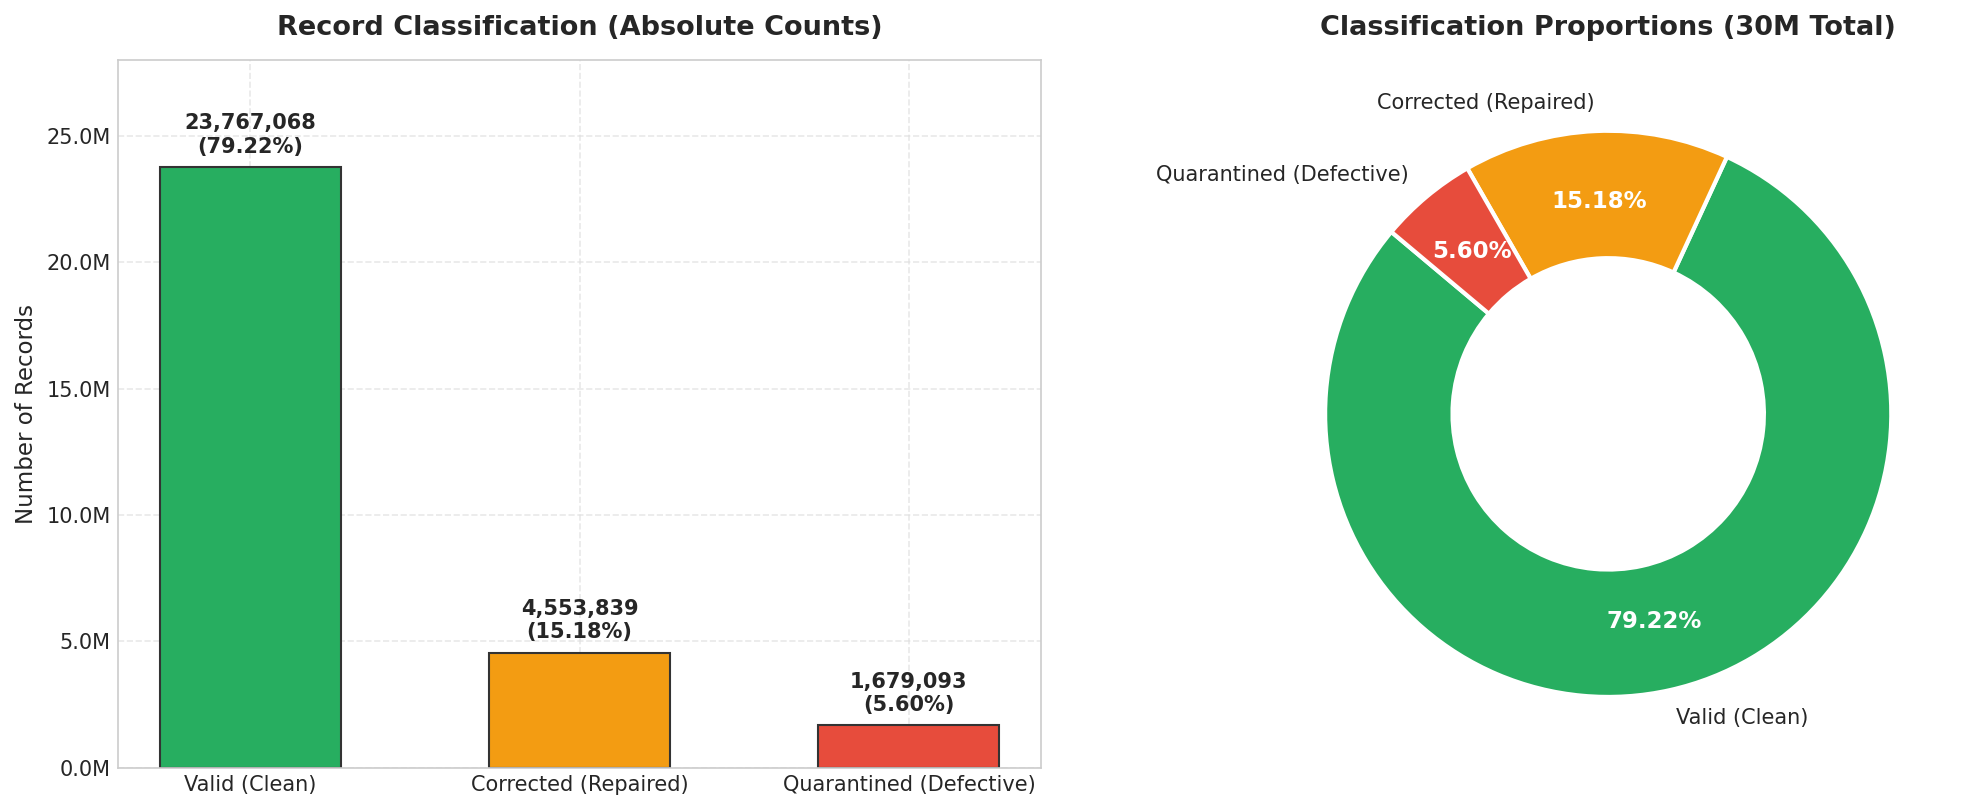

Figure saved to: ..\docs\screenshots\eda\quality_distribution_30m.png


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

labels = ['Valid (Clean)', 'Corrected (Repaired)', 'Quarantined (Defective)']
counts = [metrics_30m['count_valid'], metrics_30m['count_corrected'], metrics_30m['count_quarantine']]
colors = ['#27ae60', '#f39c12', '#e74c3c']

# 1. Bar Chart (Absolute Counts)
bars = ax1.bar(labels, counts, color=colors, width=0.55, edgecolor='#333333', linewidth=1)
ax1.set_title('Record Classification (Absolute Counts)', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Number of Records', fontsize=11)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x*1e-6:.1f}M'))
ax1.set_ylim(0, 28_000_000)

for bar in bars:
    height = bar.get_height()
    pct = (height / sum(counts)) * 100
    ax1.annotate(f'{height:,}\n({pct:.2f}%)',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5), textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Donut Chart (Proportions)
wedges, texts, autotexts = ax2.pie(
    counts, labels=labels, autopct='%1.2f%%', startangle=140,
    colors=colors, wedgeprops=dict(width=0.45, edgecolor='#ffffff', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 10}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax2.set_title('Classification Proportions (30M Total)', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
fig_path = os.path.join(EDA_FIGURES_DIR, "quality_distribution_30m.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {fig_path}")

---
## 4. Deterministic Quality Rules Analysis (RULE_01 – RULE_10)

The transformation layer applies **10 strictly deterministic rules** to repair dirty data while logging exact field-level audit trails:

| Rule Code | Rule Description | Measured 30M Count | Corrective Action |
|---|---|---|---|
| **RULE_01** | Arabic Digits Normalization | **1,003,269** | Converts Eastern Arabic numerals (`٧٠٦٠٠٠٫٠` $\to$ `706000.0`) |
| **RULE_05** | Phone Number Normalization | **670,062** | Formats Yemeni phone strings to standard 9-digit format (`771234567`) |
| **RULE_07** | Date Format Standardization | **668,151** | Standardizes varied date formats (`DD-MM-YYYY` $\to$ ISO 8601) |
| **RULE_06** | Email Syntax Cleanup | **667,720** | Removes repeated `@` or `.` symbols in repairable emails |
| **RULE_09** | Order Total Recalculation | **500,976** | Resolves `???` or formula mismatches ($\sum \text{items} + \text{delivery}$) |
| **RULE_02** | Currency Normalization | **333,888** | Strips embedded currency text; assigns canonical `YER` |
| **RULE_04** | Known Number Words | **333,569** | Maps written Arabic words (`ألفان` $\to$ `2000.0`) |
| **RULE_03** | Thousands Separators | **333,494** | Strips embedded commas inside numeric strings (`125,000` $\to$ `125000`) |
| **RULE_10** | Negative Payment Sign Matching | **209,114** | Converts negative payment sign when absolute payment equals valid order total |
| **RULE_08** | Whitespace Trim & Synonyms | *Flow Integrated* | Standardizes city/status synonyms; integrated in core processing |

> **Note on RULE_08:** RULE_08 (whitespace trimming and canonical synonym normalization) is executed as part of the core text processing flow for all candidate records. Its standalone trigger count is not isolated as a separate corrective audit flag in the summary metrics.

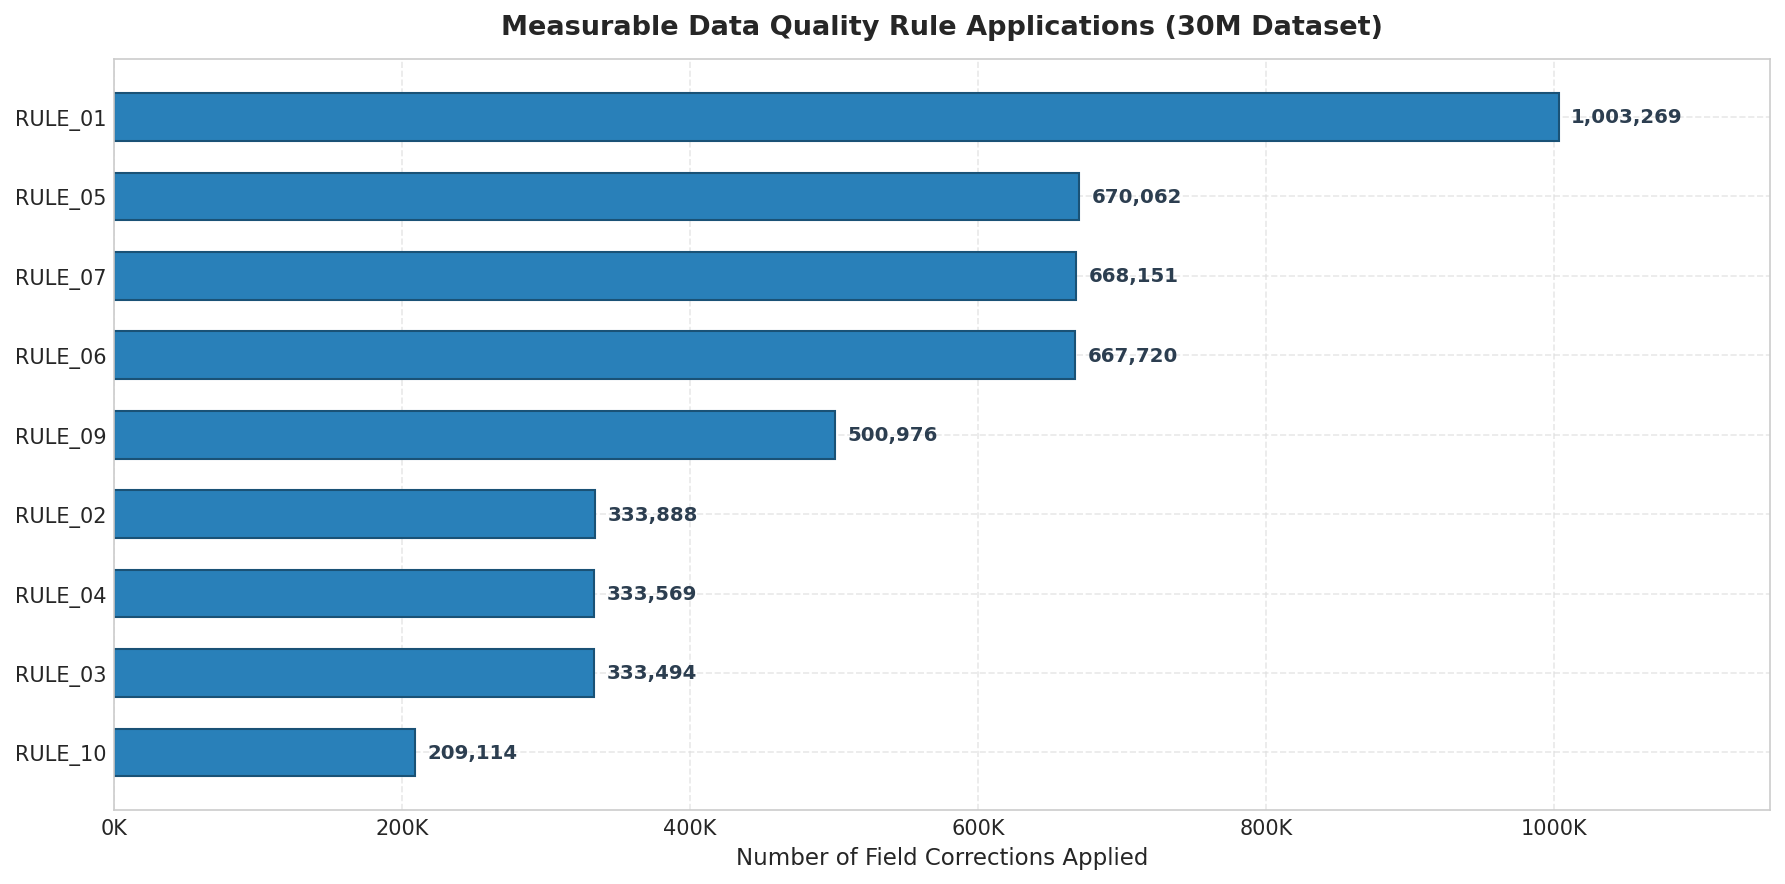

Total measurable rule applications: 4,720,243


In [4]:
rules_data = metrics_30m["rule_case_counts"]
df_rules = pd.DataFrame(list(rules_data.items()), columns=["Rule Code", "Trigger Count"])
df_rules = df_rules.sort_values(by="Trigger Count", ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_rules["Rule Code"], df_rules["Trigger Count"], color='#2980b9', edgecolor='#1a5276', height=0.6)

ax.set_title('Measurable Data Quality Rule Applications (30M Dataset)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Field Corrections Applied', fontsize=11)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x*1e-3:.0f}K'))
ax.set_xlim(0, 1_150_000)

for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:,}',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0), textcoords="offset points",
                ha='left', va='center', fontsize=9.5, fontweight='bold', color='#2c3e50')

plt.tight_layout()
fig_path = os.path.join(EDA_FIGURES_DIR, "rule_distribution_30m.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Total measurable rule applications: {df_rules['Trigger Count'].sum():,}")

---
## 5. Quarantine Defect Analysis

Records with fatal, non-repairable defects are segregated into `orders_quarantine` with distinct error codes.

### Error Occurrence Distribution
- `CORRUPTED_ITEMS_JSON` (629,924): Malformed or truncated JSON strings in `items_json`.
- `MISSING_CUSTOMER_ID` (419,474): Missing or empty customer reference.
- `UNSAFE_EMAIL` (418,709): Irrecoverably malformed email syntax (missing domain or username).
- `INVALID_IMPOSSIBLE_DATE` (210,524): Non-existent calendar dates (e.g. 31-Feb or year outside 2000–2030).
- `EMPTY_ITEMS` (209,934): Valid JSON structure but 0 line items.
- `MULTIPLE_CONFLICTING_ERRORS` (209,432): Records triggering multiple simultaneous errors.
- `MISSING_ORDER_ID` (209,392): Missing or blank primary order identifier.

> **Important Data Architecture Note:** Because individual records can contain multiple simultaneous data defects (such as both a corrupted JSON payload and a missing customer ID), error occurrences are tracked independently. The total quarantined document count is exactly **1,679,093**.

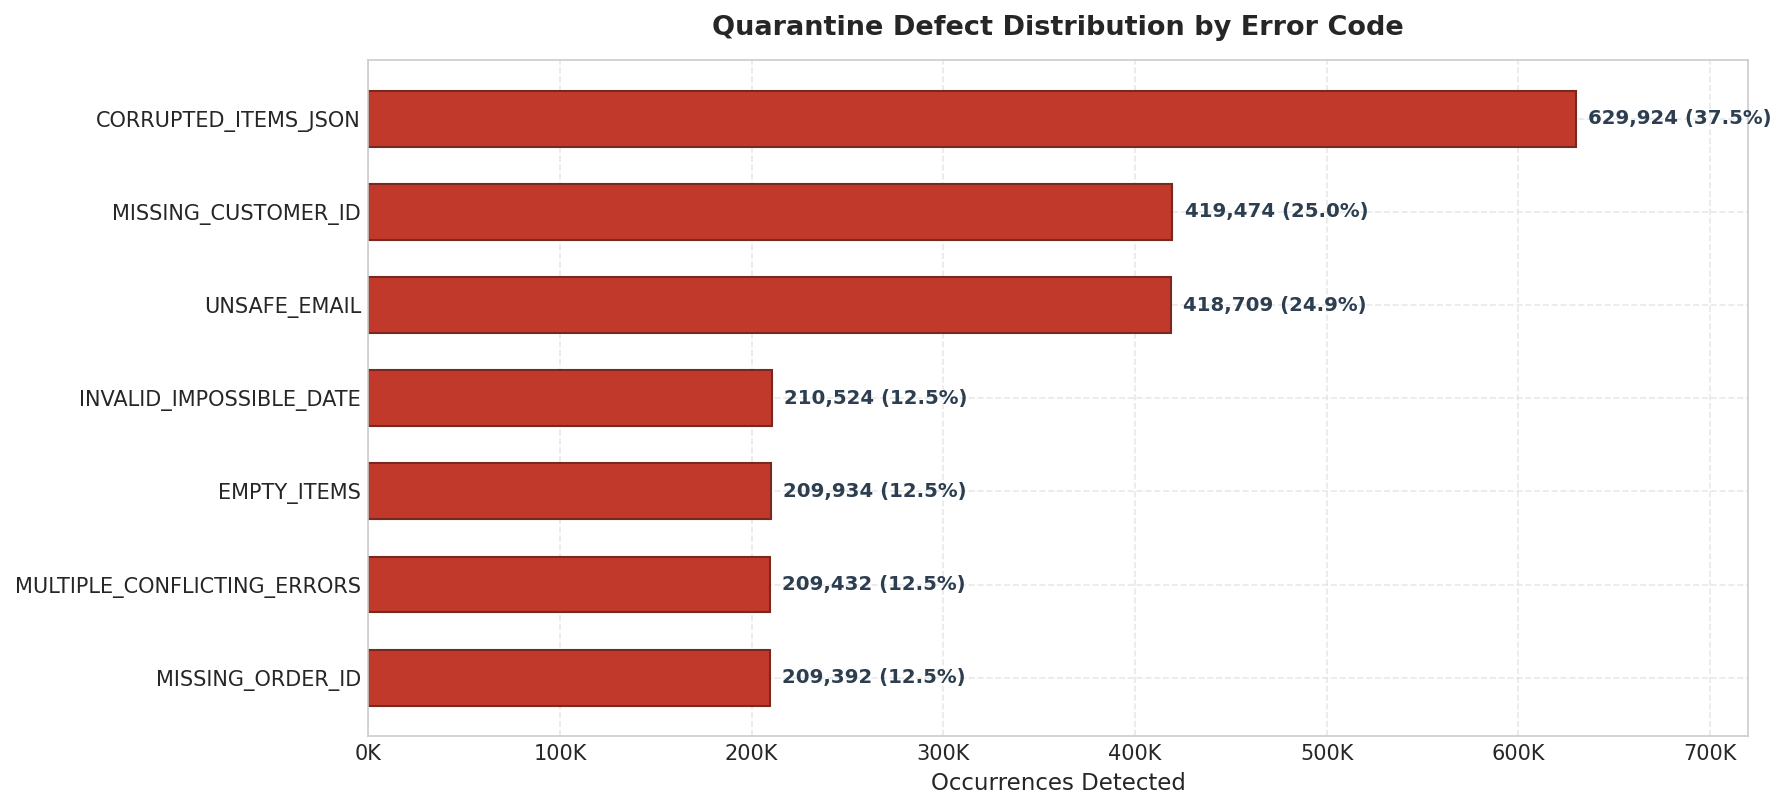

Figure saved to: ..\docs\screenshots\eda\quarantine_reasons_30m.png


In [5]:
errors_data = metrics_30m["error_case_counts"]
df_errors = pd.DataFrame(list(errors_data.items()), columns=["Error Code", "Occurrences"])
df_errors = df_errors.sort_values(by="Occurrences", ascending=True)

fig, ax = plt.subplots(figsize=(12, 5.5))
bars = ax.barh(df_errors["Error Code"], df_errors["Occurrences"], color='#c0392b', edgecolor='#78281f', height=0.6)

ax.set_title('Quarantine Defect Distribution by Error Code', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Occurrences Detected', fontsize=11)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x*1e-3:.0f}K'))
ax.set_xlim(0, 720_000)

for bar in bars:
    width = bar.get_width()
    pct = (width / metrics_30m["count_quarantine"]) * 100
    ax.annotate(f'{width:,} ({pct:.1f}%)',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0), textcoords="offset points",
                ha='left', va='center', fontsize=9.5, fontweight='bold', color='#2c3e50')

plt.tight_layout()
fig_path = os.path.join(EDA_FIGURES_DIR, "quarantine_reasons_30m.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {fig_path}")

---
## 6. Raw vs. Validated vs. Quarantine Collection Dynamics

An essential architectural property of this pipeline is **Business Key Entity Stability**:

| Collection | Stored Documents | Description |
|---|---|---|
| **`orders_raw`** | **30,000,000** | 100% of all ingested CSV rows preserved as raw strings. |
| **`orders_validated`** | **28,121,300** | Unique business orders (valid + corrected) stored with `$jsonSchema`. |
| **`orders_quarantine`** | **1,679,093** | Defective records isolated with compound unique key `(id_run, source_row_number)`. |

### Why Validated + Quarantine $\ne$ Raw Document Count:
$$\text{Validated Documents} (28,121,300) + \text{Quarantine Documents} (1,679,093) = 29,800,393 \ne 30,000,000$$

This difference occurs because the source CSV contains **199,607 duplicate valid order records**.  
Because `orders_validated` enforces an **Idempotent Upsert (`UpdateOne(..., upsert=True)`) on `id_order`**, when a duplicate order record arrives:
- The newer version updates the existing entity in place (`$set`), rather than inserting a second document.
- Exact reconciliation: $28,121,300 \text{ (Inserted)} + 199,607 \text{ (Updated)} = 28,320,907 \text{ (Total Valid+Corrected Rows)}$.
- Total consistency: $28,320,907 \text{ (Valid+Corrected Rows)} + 1,679,093 \text{ (Quarantined Rows)} = 30,000,000 \text{ (Raw Rows)}$.

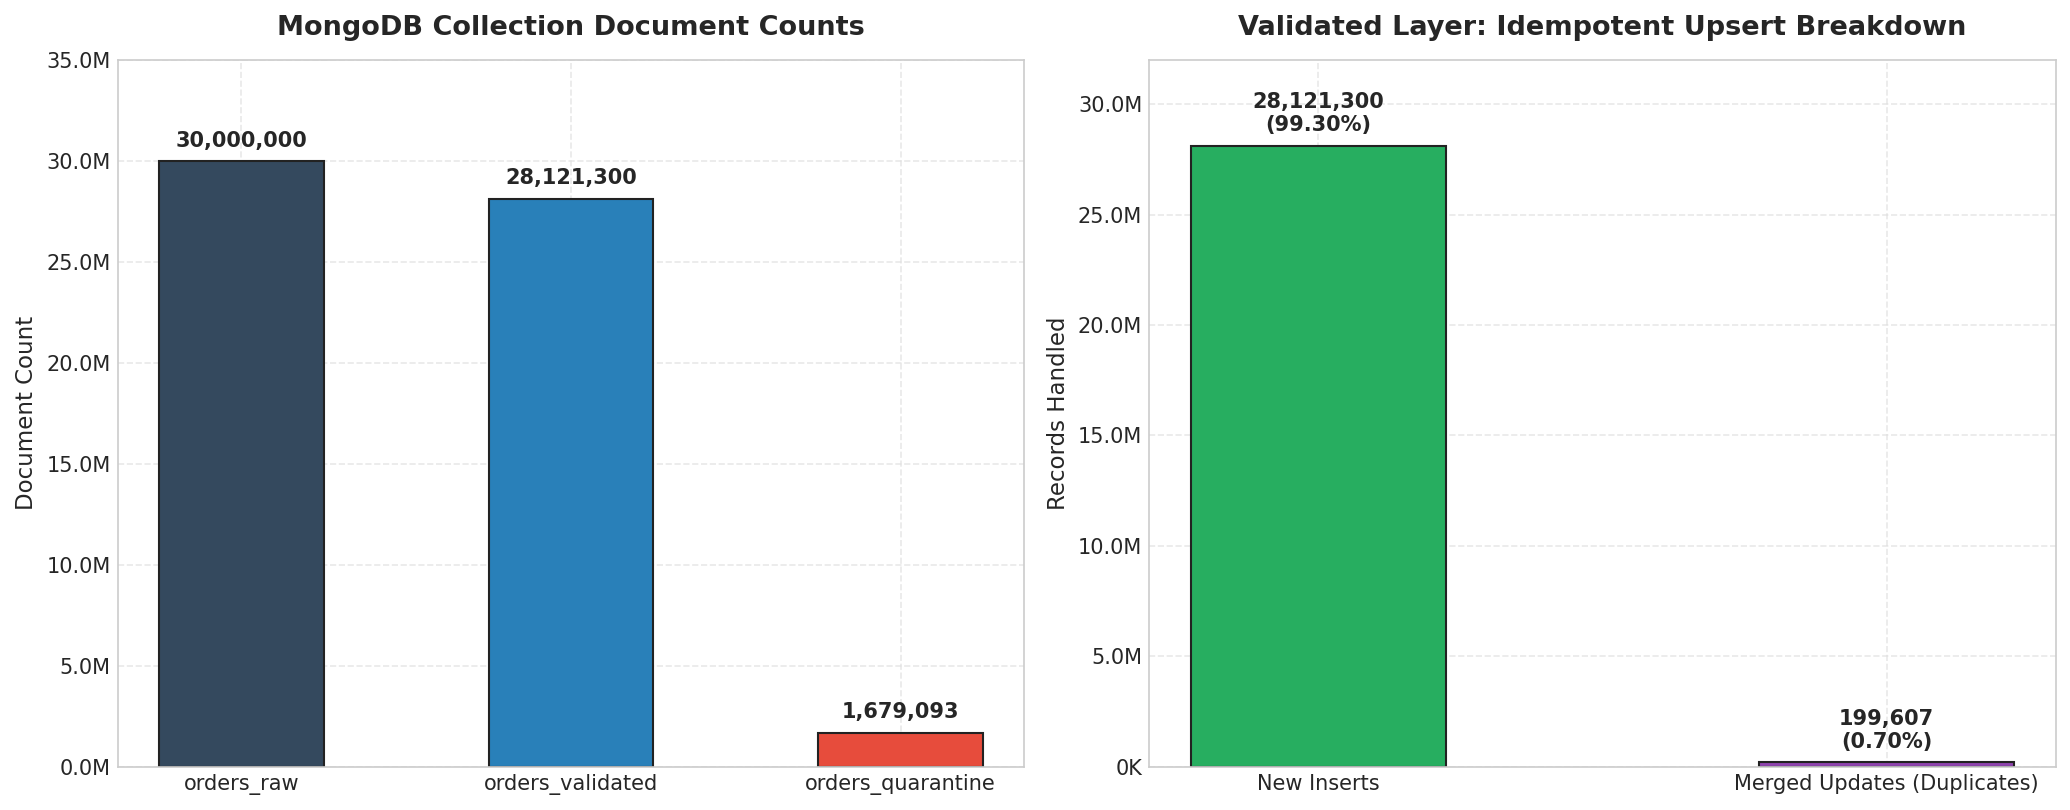

Figure saved to: ..\docs\screenshots\eda\collection_counts_30m.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# 1. MongoDB Document Counts
collections = ['orders_raw', 'orders_validated', 'orders_quarantine']
counts_col = [30_000_000, 28_121_300, 1_679_093]
colors_col = ['#34495e', '#2980b9', '#e74c3c']

bars1 = ax1.bar(collections, counts_col, color=colors_col, width=0.5, edgecolor='#222222', linewidth=1)
ax1.set_title('MongoDB Collection Document Counts', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Document Count', fontsize=11)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x*1e-6:.1f}M'))
ax1.set_ylim(0, 35_000_000)

for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5), textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Upsert Breakdown for Validated Orders
upsert_labels = ['New Inserts', 'Merged Updates (Duplicates)']
upsert_counts = [metrics_30m['count_inserted'], metrics_30m['count_updated']]
colors_upsert = ['#27ae60', '#8e44ad']

bars2 = ax2.bar(upsert_labels, upsert_counts, color=colors_upsert, width=0.45, edgecolor='#222222', linewidth=1)
ax2.set_title('Validated Layer: Idempotent Upsert Breakdown', fontsize=13, fontweight='bold', pad=12)
ax2.set_ylabel('Records Handled', fontsize=11)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x*1e-6:.1f}M' if x >= 1e6 else f'{x*1e-3:.0f}K'))
ax2.set_ylim(0, 32_000_000)

for bar in bars2:
    height = bar.get_height()
    pct = (height / sum(upsert_counts)) * 100
    ax2.annotate(f'{height:,}\n({pct:.2f}%)',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5), textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
fig_path = os.path.join(EDA_FIGURES_DIR, "collection_counts_30m.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {fig_path}")

---
## 7. Financial Data Quality Verification

The pipeline guarantees strict financial correctness enforced at both the transformation layer and the database layer (`$jsonSchema` `minimum: 0.0`):

| Financial Constraint | Production Verification Result | Conformance Status |
|---|---|:---:|
| Negative `payment_amount` in `orders_validated` | **0** (Zero occurrences) | ✅ **PASS** |
| Negative `total_amount` in `orders_validated` | **0** (Zero occurrences) | ✅ **PASS** |
| Negative `delivery_cost` in `orders_validated` | **0** (Zero occurrences) | ✅ **PASS** |

### Safe Sample Distribution Analysis
Below, we query a sample of 2,000 validated records from the local MongoDB instance to illustrate the financial distribution across order amounts, payment methods, and delivery costs without loading the entire 28M collection into RAM.

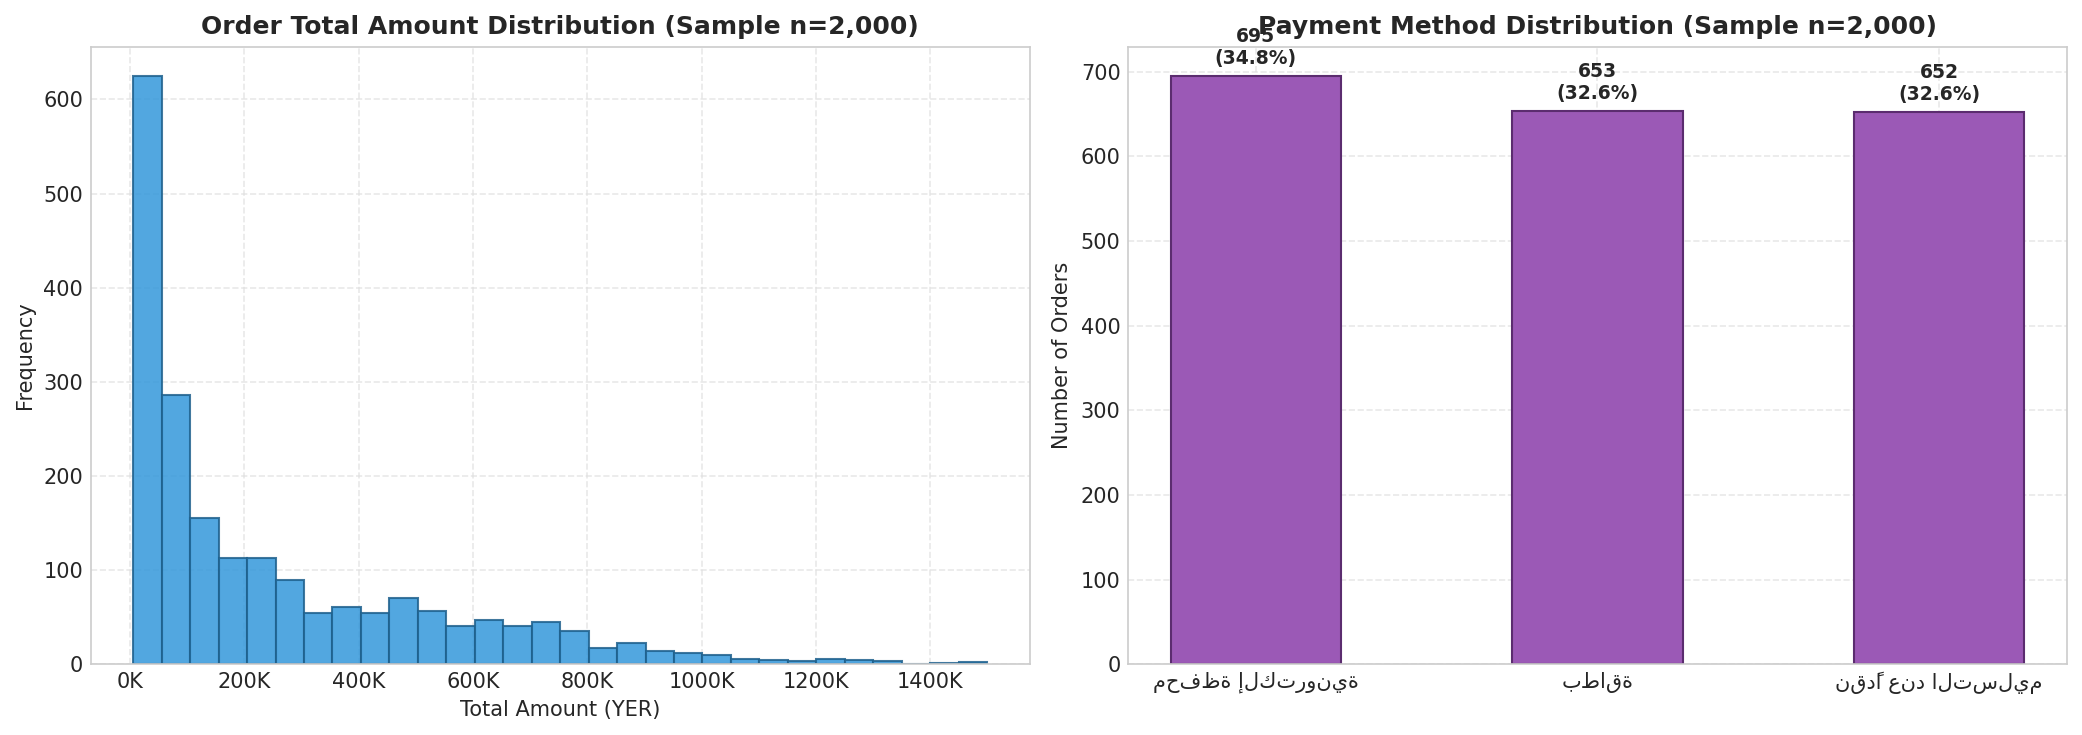

Sample mean order amount: 256,465.25 YER
Sample min order amount:  6,000.00 YER (strictly non-negative)


In [7]:
# Connect to local MongoDB safely for limited sample extraction
client = MongoClient("mongodb://localhost:27017/")
db = client[metrics_30m["database_name"]]

# Retrieve a memory-safe representative sample of 2,000 documents
cursor = db["orders_validated"].find(
    {},
    {"_id": 0, "id_order": 1, "total_amount": 1, "payment_amount": 1, "delivery_cost": 1, "payment_method": 1, "delivery_type": 1}
).limit(2000)

df_sample = pd.DataFrame(list(cursor))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Total Order Amount Distribution (Sample)
ax1.hist(df_sample["total_amount"], bins=30, color='#3498db', edgecolor='#1f618d', alpha=0.85)
ax1.set_title('Order Total Amount Distribution (Sample n=2,000)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Amount (YER)', fontsize=10)
ax1.set_ylabel('Frequency', fontsize=10)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x*1e-3:.0f}K'))

# 2. Payment Method Breakdown (Sample)
method_counts = df_sample["payment_method"].value_counts()
bars_m = ax2.bar(method_counts.index, method_counts.values, color='#9b59b6', edgecolor='#5b2c6f', width=0.5)
ax2.set_title('Payment Method Distribution (Sample n=2,000)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Orders', fontsize=10)

for bar in bars_m:
    height = bar.get_height()
    pct = (height / len(df_sample)) * 100
    ax2.annotate(f'{height}\n({pct:.1f}%)',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 4), textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Sample mean order amount: {df_sample['total_amount'].mean():,.2f} YER")
print(f"Sample min order amount:  {df_sample['total_amount'].min():,.2f} YER (strictly non-negative)")

---
## 8. Source Row Number Integrity & Partition-Offset Solution

### The Challenge with PySpark `monotonically_increasing_id()`
In PySpark, `monotonically_increasing_id()` encodes partition IDs in the high 33 bits, resulting in sparse identifiers up to 51 billion (e.g., `25769803780`). This violated our MongoDB schema requirement for BSON `Int32` and did not reflect true physical CSV line numbers ($1 \dots N$).

### The Engineered Spark-Native Cumulative Partition-Offset Algorithm
```python
# 1. Per-partition aggregation
df_with_pid = df_csv.withColumn("_pid", spark_partition_id())
part_counts = df_with_pid.groupBy("_pid").count().orderBy("_pid").collect()  # Driver collects only 99 integers (<2 KB)

# 2. Build cumulative partition offsets
offsets, cum = [], 0
for row in part_counts:
    offsets.append((int(row["_pid"]), int(cum)))
    cum += int(row["count"])
offsets_df = spark.createDataFrame(offsets, ["_pid", "_offset"])

# 3. Compute deterministic sequential row numbers
w = Window.partitionBy("_pid").orderBy(lit(1))
df_indexed = (
    df_with_pid.join(offsets_df, on="_pid")
    .withColumn("source_row_number", (col("_offset") + row_number().over(w)).cast(IntegerType()))
    .drop("_pid", "_offset")
)
```

### Empirical Verification:
- **Minimum `source_row_number`:** `1`
- **Maximum `source_row_number`:** `30,000,000`
- **Gaps / Duplicates:** `0` (100% gapless consecutive lineage)
- **MongoDB BSON Type:** `Int32` (BSON Type 16)

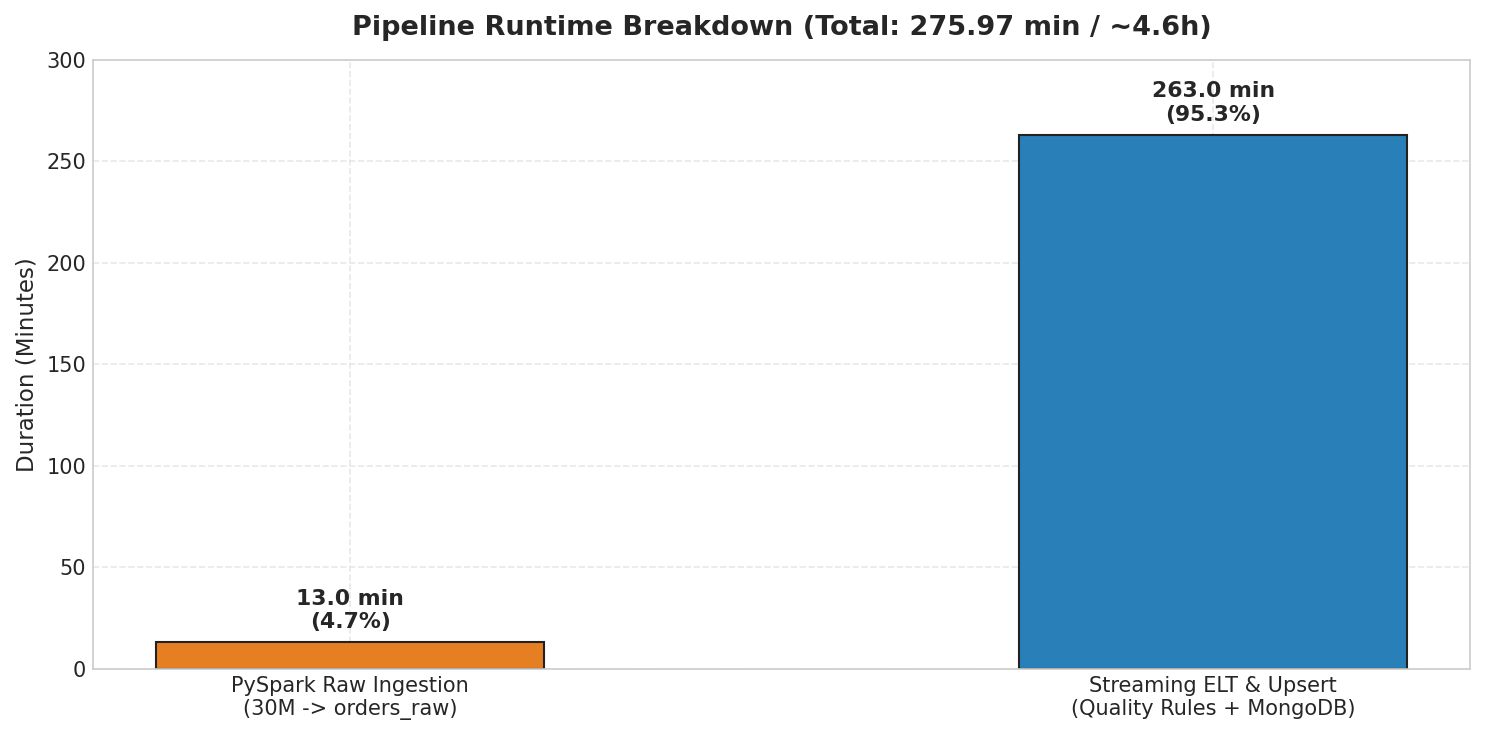

Figure saved to: ..\docs\screenshots\eda\runtime_breakdown_30m.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

phases = ['PySpark Raw Ingestion\n(30M -> orders_raw)', 'Streaming ELT & Upsert\n(Quality Rules + MongoDB)']
times_min = [13.0, 262.97]  # ~13 min ingestion, ~263 min ELT
colors_time = ['#e67e22', '#2980b9']

bars_t = ax.bar(phases, times_min, color=colors_time, width=0.45, edgecolor='#222222', linewidth=1)
ax.set_title('Pipeline Runtime Breakdown (Total: 275.97 min / ~4.6h)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Duration (Minutes)', fontsize=11)
ax.set_ylim(0, 300)

for bar in bars_t:
    height = bar.get_height()
    pct = (height / sum(times_min)) * 100
    ax.annotate(f'{height:.1f} min\n({pct:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=10.5, fontweight='bold')

plt.tight_layout()
fig_path = os.path.join(EDA_FIGURES_DIR, "runtime_breakdown_30m.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {fig_path}")

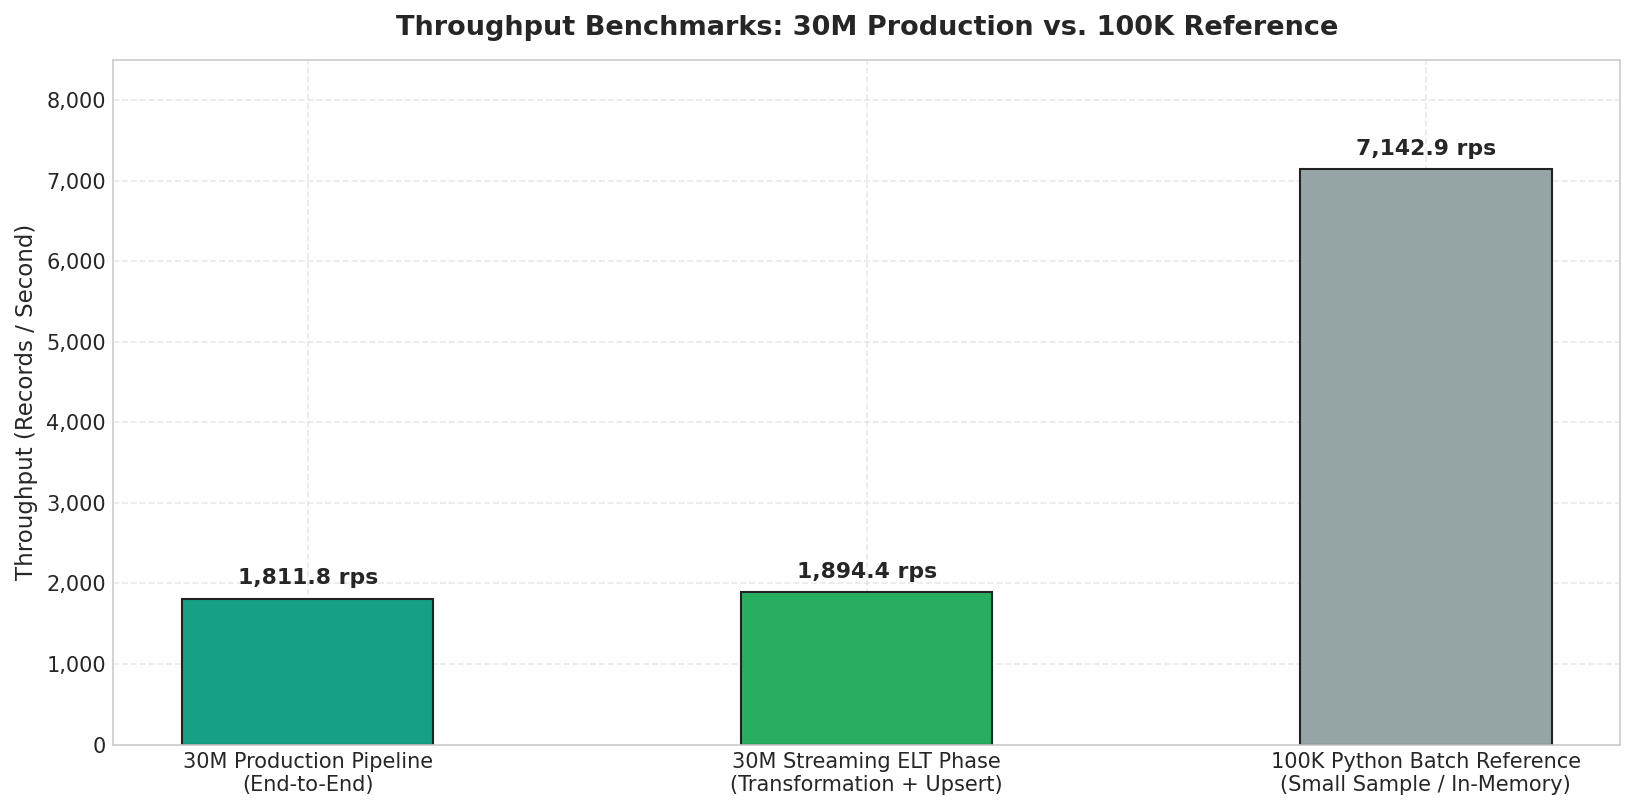

Figure saved to: ..\docs\screenshots\eda\throughput_30m.png


In [9]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Explicit labeling to clearly distinguish 30M production throughput from 100K in-memory reference
stages = [
    '30M Production Pipeline\n(End-to-End)',
    '30M Streaming ELT Phase\n(Transformation + Upsert)',
    '100K Python Batch Reference\n(Small Sample / In-Memory)'
]
rates = [metrics_30m['throughput'], 1894.43, 7142.86]
colors_rate = ['#16a085', '#27ae60', '#95a5a6']

bars_r = ax.bar(stages, rates, color=colors_rate, width=0.45, edgecolor='#222222', linewidth=1)
ax.set_title('Throughput Benchmarks: 30M Production vs. 100K Reference', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Throughput (Records / Second)', fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.set_ylim(0, 8500)

for bar in bars_r:
    height = bar.get_height()
    ax.annotate(f'{height:,.1f} rps',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=10.5, fontweight='bold')

plt.tight_layout()
fig_path = os.path.join(EDA_FIGURES_DIR, "throughput_30m.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {fig_path}")

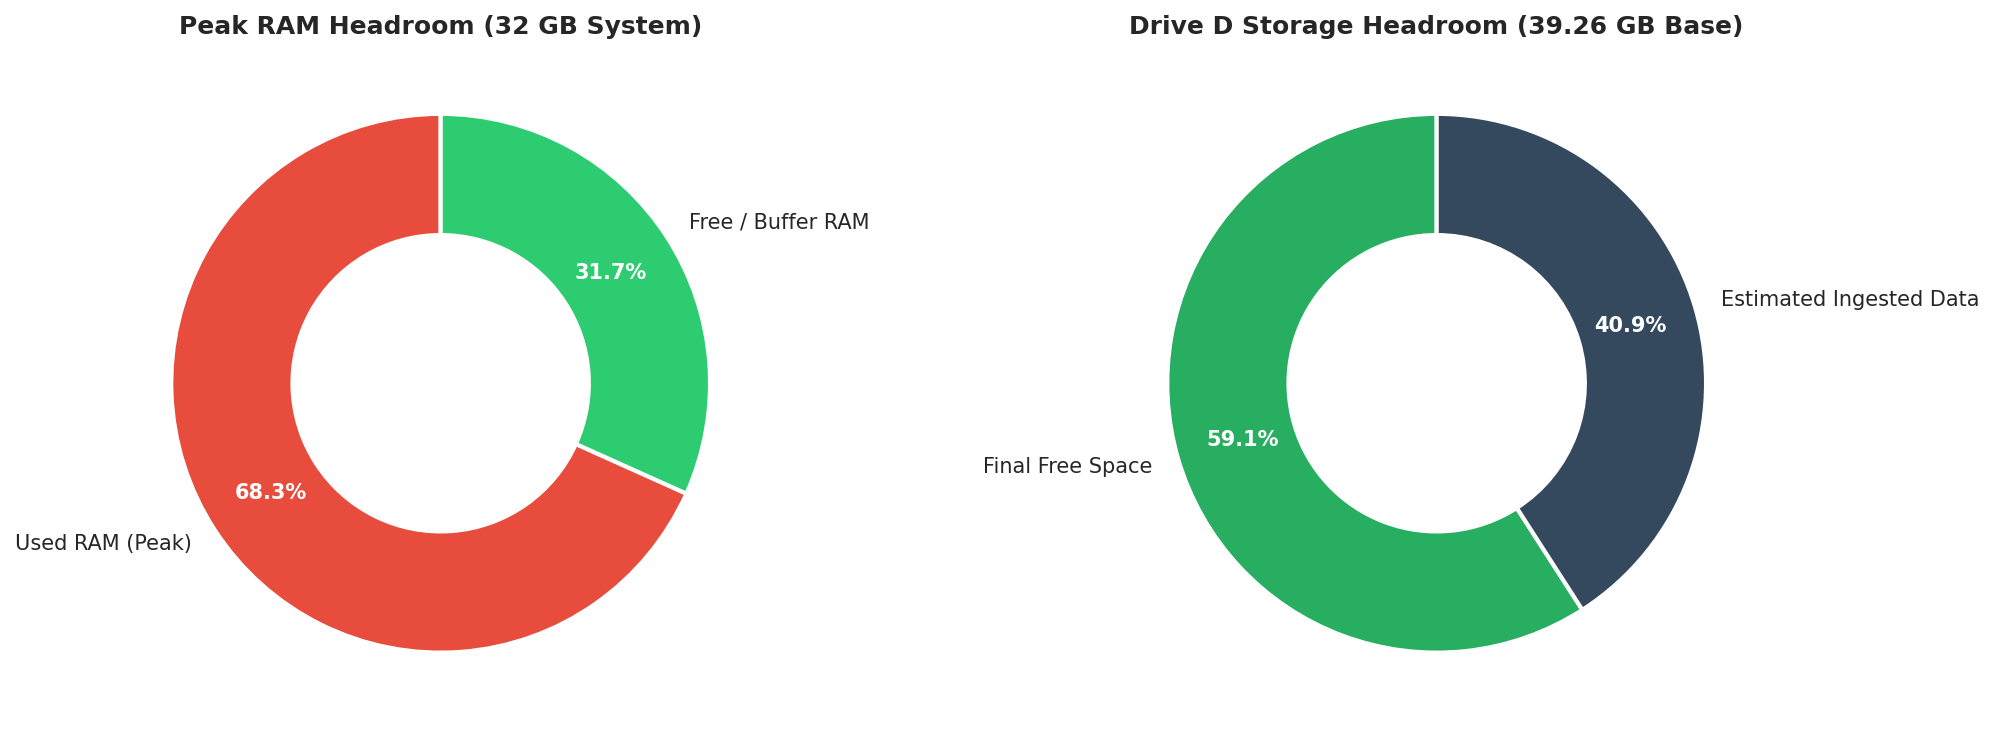

Figure saved to: ..\docs\screenshots\eda\resource_usage_30m.png


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. RAM Utilization
ram_labels = ['Used RAM (Peak)', 'Free / Buffer RAM']
ram_vals = [21.85, 32.0 - 21.85]
colors_ram = ['#e74c3c', '#2ecc71']

wedges, texts, autotexts = ax1.pie(
    ram_vals, labels=ram_labels, autopct='%1.1f%%', startangle=90,
    colors=colors_ram, wedgeprops=dict(width=0.45, edgecolor='#ffffff', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 10}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax1.set_title('Peak RAM Headroom (32 GB System)', fontsize=12, fontweight='bold')

# 2. Disk Space Headroom (Drive D)
disk_labels = ['Final Free Space', 'Estimated Ingested Data']
disk_vals = [23.2, 16.06]
colors_disk = ['#27ae60', '#34495e']

wedges2, texts2, autotexts2 = ax2.pie(
    disk_vals, labels=disk_labels, autopct='%1.1f%%', startangle=90,
    colors=colors_disk, wedgeprops=dict(width=0.45, edgecolor='#ffffff', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 10}
)
for autotext in autotexts2:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax2.set_title('Drive D Storage Headroom (39.26 GB Base)', fontsize=12, fontweight='bold')

plt.tight_layout()
fig_path = os.path.join(EDA_FIGURES_DIR, "resource_usage_30m.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {fig_path}")

---
## 12. Scaling Comparison: 100K Sample vs. 30M Production Run

A direct comparison demonstrates that the data quality distribution remains remarkably consistent between the small sample and the full-scale 30M dataset:

| Dimension / Metric | 100K Validation Sample | 30M Full-Scale Production | Scaling Behavior & Parity |
|---|---|---|---|
| **Input File** | `orders_sample_100k.csv` (41.77 MB) | `orders_30m.csv` (12,650.32 MB) | $300\times$ volume increase |
| **Engine Used** | Python Streaming Batch | PySpark Distributed DataFrame | File Router switched engines seamlessly |
| **Valid Proportion** | **79.16%** (79,158) | **79.22%** (23,767,068) | Consistent (~79.2%) |
| **Corrected Proportion** | **15.30%** (15,295) | **15.18%** (4,553,839) | Consistent (~15.2%) |
| **Quarantined Proportion** | **5.55%** (5,547) | **5.60%** (1,679,093) | Consistent (~5.6%) |
| **Accounting Equation** | $100{,}000 = 79{,}158 + 15{,}295 + 5{,}547$ | $30{,}000{,}000 = 23{,}767{,}068 + 4{,}553{,}839 + 1{,}679{,}093$ | **PASS** on both scales |
| **Duplicate Updates** | 647 updates | 199,607 updates | Idempotent upsert verified |
| **Schema Failures** | 0 failures | 0 failures | 100% Conformance |
| **Automated Tests** | 19 / 19 PASSED | 19 / 19 PASSED | Fully Verified |

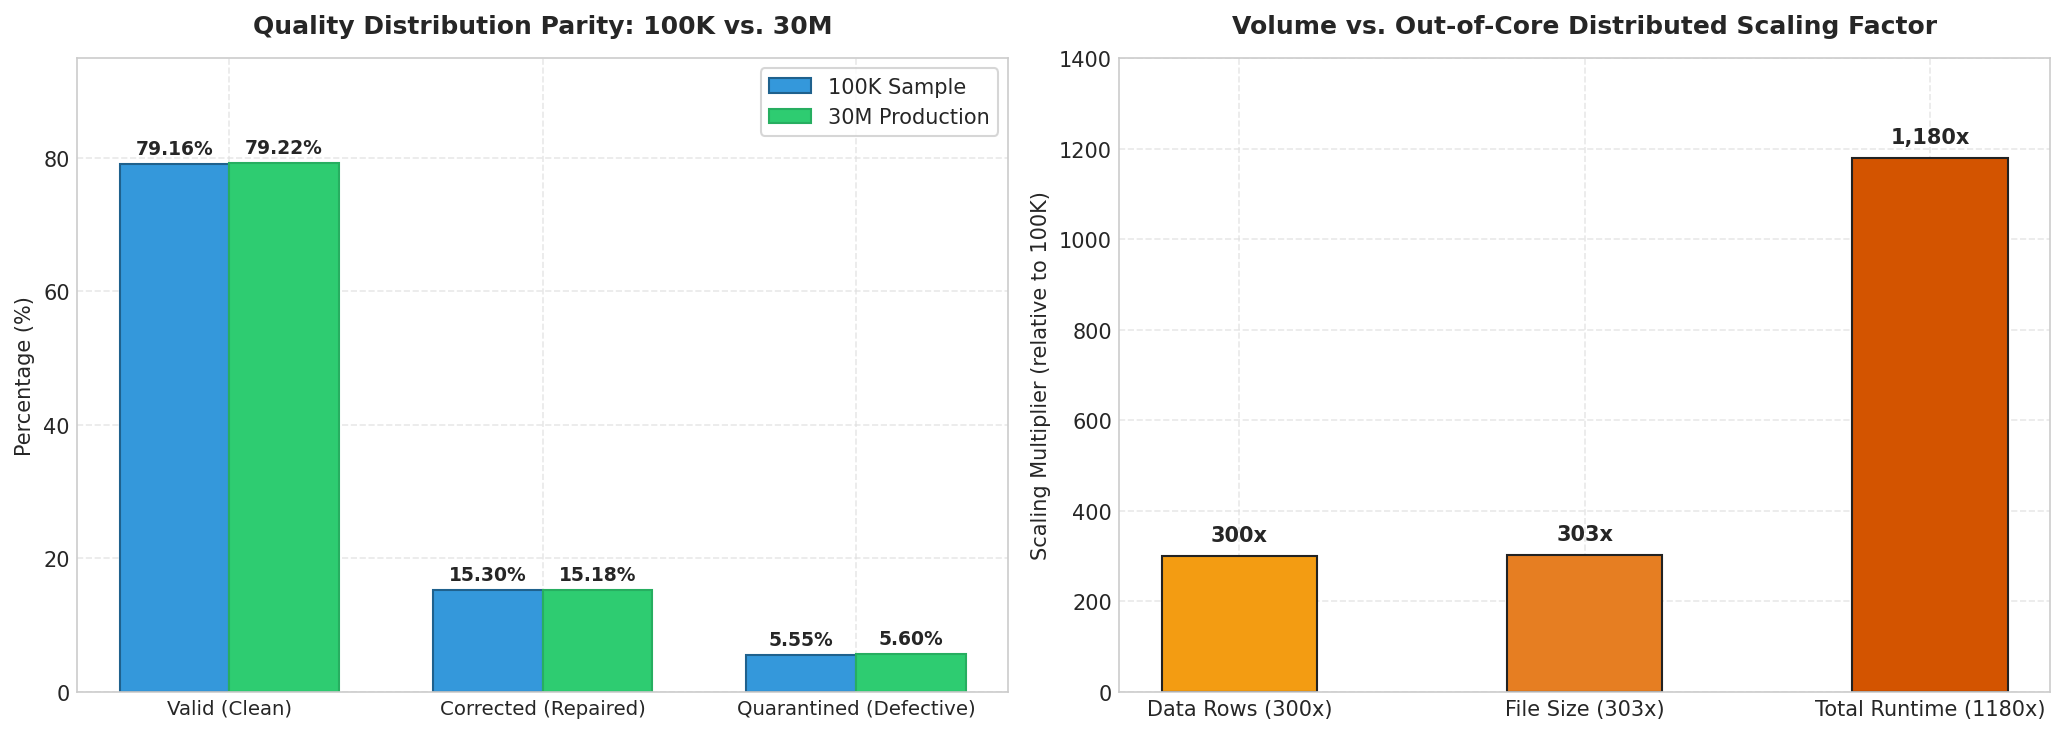

Figure saved to: ..\docs\screenshots\eda\100k_vs_30m.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Quality Proportions: 100K vs 30M
categories = ['Valid (Clean)', 'Corrected (Repaired)', 'Quarantined (Defective)']
pct_100k = [79.16, 15.30, 5.55]
pct_30m = [79.22, 15.18, 5.60]

x = np.arange(len(categories))
width = 0.35

ax1.bar(x - width/2, pct_100k, width, label='100K Sample', color='#3498db', edgecolor='#1f618d')
ax1.bar(x + width/2, pct_30m, width, label='30M Production', color='#2ecc71', edgecolor='#27ae60')

ax1.set_title('Quality Distribution Parity: 100K vs. 30M', fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel('Percentage (%)', fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=9.5)
ax1.set_ylim(0, 95)
ax1.legend(frameon=True, facecolor='white')

for i in range(len(categories)):
    ax1.annotate(f'{pct_100k[i]:.2f}%', (x[i] - width/2, pct_100k[i] + 1.5), ha='center', fontsize=9, fontweight='bold')
    ax1.annotate(f'{pct_30m[i]:.2f}%', (x[i] + width/2, pct_30m[i] + 1.5), ha='center', fontsize=9, fontweight='bold')

# 2. Scaling Factors: Data Volume vs Runtime
scales = ['Data Rows (300x)', 'File Size (303x)', 'Total Runtime (1180x)']
vals = [300, 303, 1180]
colors_scale = ['#f39c12', '#e67e22', '#d35400']

bars_s = ax2.bar(scales, vals, color=colors_scale, width=0.45, edgecolor='#222222', linewidth=1)
ax2.set_title('Volume vs. Out-of-Core Distributed Scaling Factor', fontsize=12, fontweight='bold', pad=12)
ax2.set_ylabel('Scaling Multiplier (relative to 100K)', fontsize=10)
ax2.set_ylim(0, 1400)

for bar in bars_s:
    height = bar.get_height()
    ax2.annotate(f'{height:,.0f}x',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5), textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
fig_path = os.path.join(EDA_FIGURES_DIR, "100k_vs_30m.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {fig_path}")

---
## 13. Key Technical Findings

1. **Intelligent Engine Routing:** The hybrid File Router successfully routed the 12.65 GB CSV to PySpark ($>200$ MB threshold), achieving distributed parallel multi-partition ingestion across 99 partitions.
2. **Strict Conservation of Data (Accounting Equation PASS):** Every single input record is deterministically accounted for ($30{,}000{,}000 = 23{,}767{,}068 + 4{,}553{,}839 + 1{,}679{,}093$).
3. **Zero Schema Violations:** Formal MongoDB `$jsonSchema` validation on `orders_validated` completed with **0 rejection errors** across 28,121,300 documents.
4. **Idempotency with Stable Business Key:** Idempotent upserting (`UpdateOne(..., upsert=True)`) safely merged **199,607 duplicate order occurrences** while ensuring exactly **0 duplicate `id_order` entries** in the validated collection.
5. **Memory-Safe Lineage Tracking:** The engineered native partition-offset algorithm achieved gapless sequential line numbers ($1 \dots 30{,}000{,}000$) in BSON `Int32` while collecting only **< 2 KB of partition metadata to the Driver**.
6. **Robust Rule Correction:** Over **4.72 million field-level repairs** were executed across RULE_01–RULE_10 with complete audit trail provenance.
7. **Resource Headroom:** Peak RAM remained bounded at **21.85 GB (68.0%)** on a 32 GB single-node machine with zero driver out-of-memory errors.

---
## 14. Conclusion

This exploratory data analysis demonstrates the production readiness, mathematical consistency, and computational efficiency of the Hybrid E-Commerce Data Pipeline. By combining **PySpark's distributed ingestion power** with **MongoDB's document-model flexibility, formal schema enforcement, and idempotent upsert guarantees**, the pipeline processed **30,000,000 mixed-quality records** with zero data loss, complete auditability, and robust resource safety.

---
**Report Generated:** August 2026  
**Author:** Individual Data Engineering Candidate | Razee University